# Notebook 2 - Handwritten digits

## 0. Importing modules and downloading Dataset

In [2]:
import time
import urllib
import scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram

from sklearn.utils import resample
from sklearn.datasets import load_digits
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

Instantiate the variables with the dataset name and the paths.

In [7]:
url  = "https://github.com/amplab/datascience-sp14/raw/master/lab7/mldata/mnist-original.mat"
path = "../data/mnist-original.mat"

Download and load the dataset.

In [8]:
# Download the .mat file
urllib.request.urlretrieve(url, path)

('../data/mnist-original.mat', <http.client.HTTPMessage at 0x713521def6b0>)

In [9]:
mnist = scipy.io.loadmat(path)
mnist_data  = mnist["data"].T
mnist_label = mnist["label"][0]

In [10]:
print("Number of datapoints: {}\n".format(mnist_data.shape[0]))
print("Number of features: {}\n".format(mnist_data.shape[1]))
print("List of labels: {}\n".format(np.unique(mnist_label)))

Number of datapoints: 70000

Number of features: 784

List of labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]



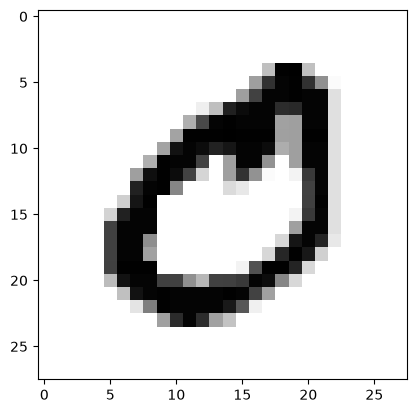

In [11]:
index = 1
image = mnist_data[index].reshape(28, 28)

plt.imshow(image, cmap=plt.cm.gray_r)
plt.show()

## 1. Preparing data 

In [12]:
# Scale the data to be either a 1 or a 0
scaled_data = mnist_data/255.0

data_train, data_test, labels_train, labels_test = train_test_split(mnist_data, mnist_label, test_size=0.2)

## 2. Training models and collecting data

In [13]:
results_df = pd.DataFrame(columns=["Model Name", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"])

In [22]:
def print_and_add(model_name, labels_test, results, training_time, results_df):

    accuracy = accuracy_score(labels_test, results)
    precision = precision_score(labels_test, results, average='weighted')
    recall = recall_score(labels_test, results, average='weighted')
    f1 = f1_score(labels_test, results, average='weighted')

    print(f"  Accuracy:       {accuracy:.4f}")
    print(f"  Precision:      {precision:.4f}")
    print(f"  Recall:         {recall:.4f}")
    print(f"  F1 Score:       {f1:.4f}")

    row = {
        "Model Name":        model_name,
        "Accuracy":          round(accuracy, 4),
        "Precision":         round(precision, 4),
        "Recall":            round(recall, 4),
        "F1 Score":          round(f1, 4),
        "Training Time (s)": round(training_time, 4)
    }

    return pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

In [23]:
# Create a kmeans model with 10 clusters
kmeans = KMeans(n_clusters=10)
kmeans.fit(scaled_data)

start = time.time()
results = kmeans.predict(data_test)    
training_time = time.time() - start

results_df = print_and_add("KMeans", labels_test, results, training_time, results_df)

  Accuracy:       0.0846
  Precision:      0.1618
  Recall:         0.0846
  F1 Score:       0.1040


Loop through the 10 clusters.

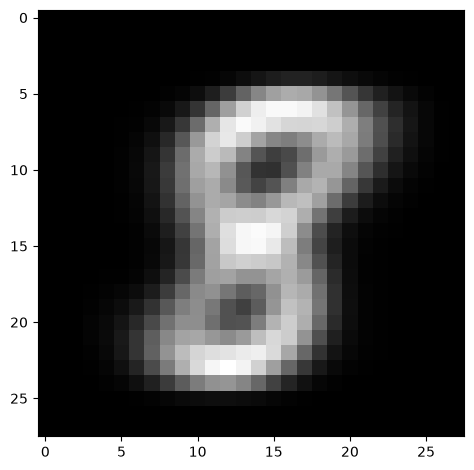

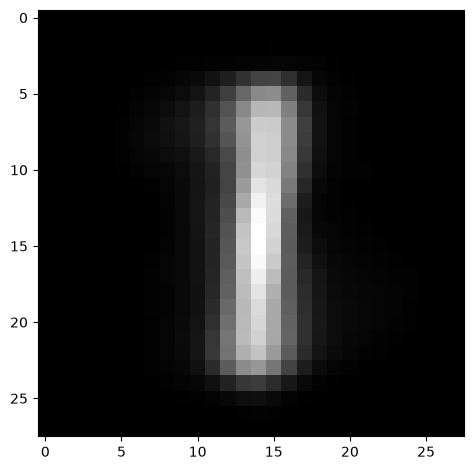

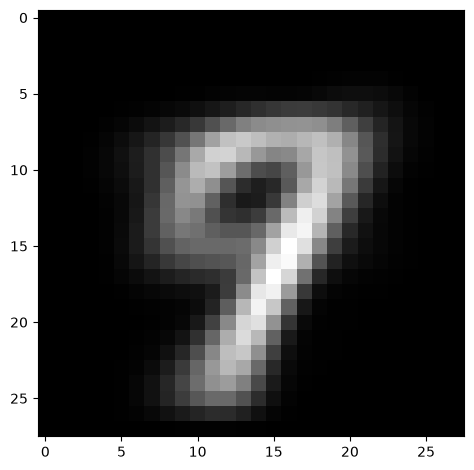

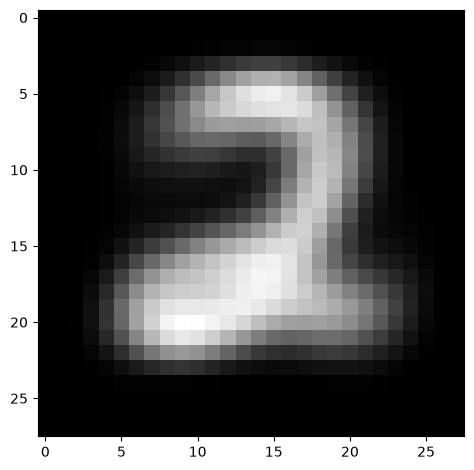

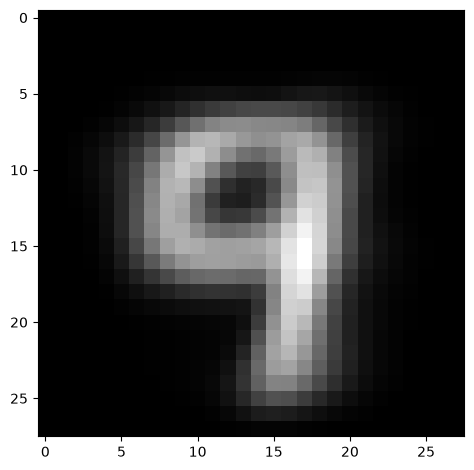

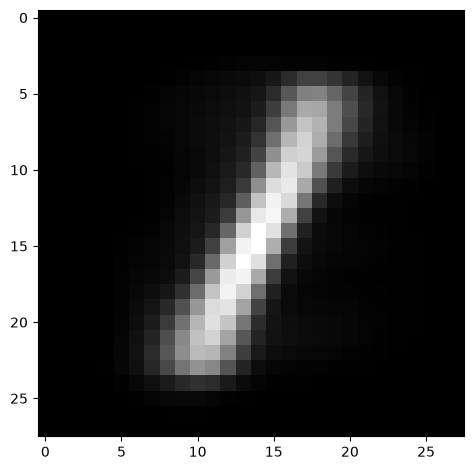

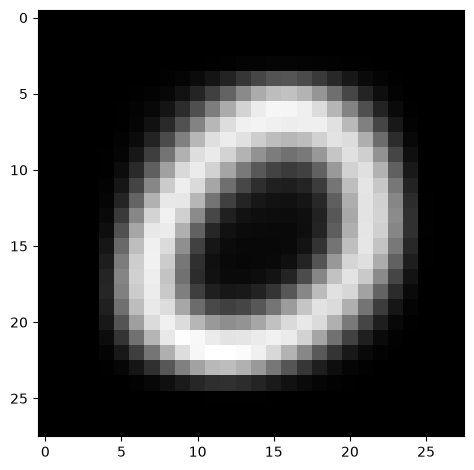

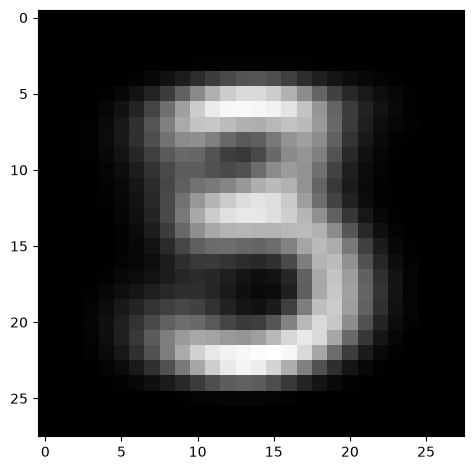

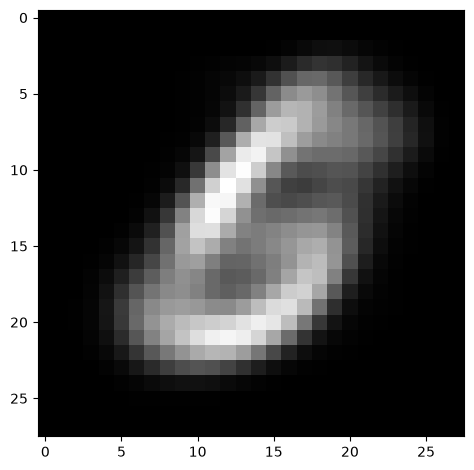

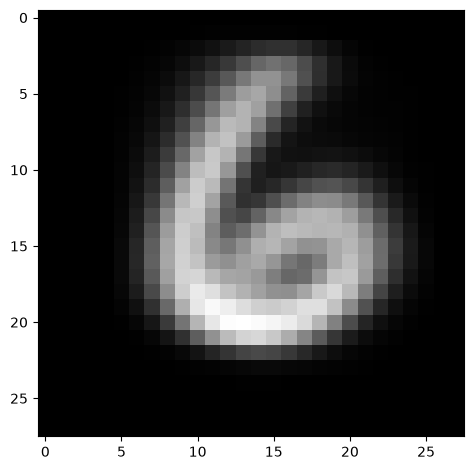

In [ ]:
for i in range(10):
  center = kmeans.cluster_centers_[i]

  image = center.reshape(28, 28)

  plt.imshow(image, cmap=plt.cm.gray)
  plt.tight_layout()
  plt.show()

Perform a supervised clustering evaluation using adjusted rand index, this is used to see if the results stable across random restarts of k-means.

In [ ]:
small_mnist_data, small_mnist_label = resample(mnist_data, mnist_label, n_samples=500, replace=False)

scaler = StandardScaler()
scaler.fit(small_mnist_data)
X_scaled = scaler.transform(small_mnist_data)

kmeans = KMeans(n_clusters=10)

# Perform 10 random restarts of kmeans and calculate the ARI for each
for i in range(10):
  labels = kmeans.fit_predict(X_scaled)

  # This allows us to determine whether the results of the clustering 
  # are stable when performing multiple random restarts of k-means.
  ari = adjusted_rand_score(labels, small_mnist_label)
  print("ARI of random restarts: {:.2f}".format(ari))

ARI of random restarts: 0.24
ARI of random restarts: 0.21
ARI of random restarts: 0.24
ARI of random restarts: 0.16
ARI of random restarts: 0.21
ARI of random restarts: 0.25
ARI of random restarts: 0.23
ARI of random restarts: 0.23
ARI of random restarts: 0.23
ARI of random restarts: 0.28


**(d)** Now perform hierarchical clustering on the data.
   (in order to improve visibility in the constructed dendrograms, you can also use a
   much reduced dataset as constructed using sklearn.utils.resample shown below).
   Does the visual analysis of the dendrogram indicate a natural number of clusters?

In [ ]:
# Define a function to plot a dendrogram
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

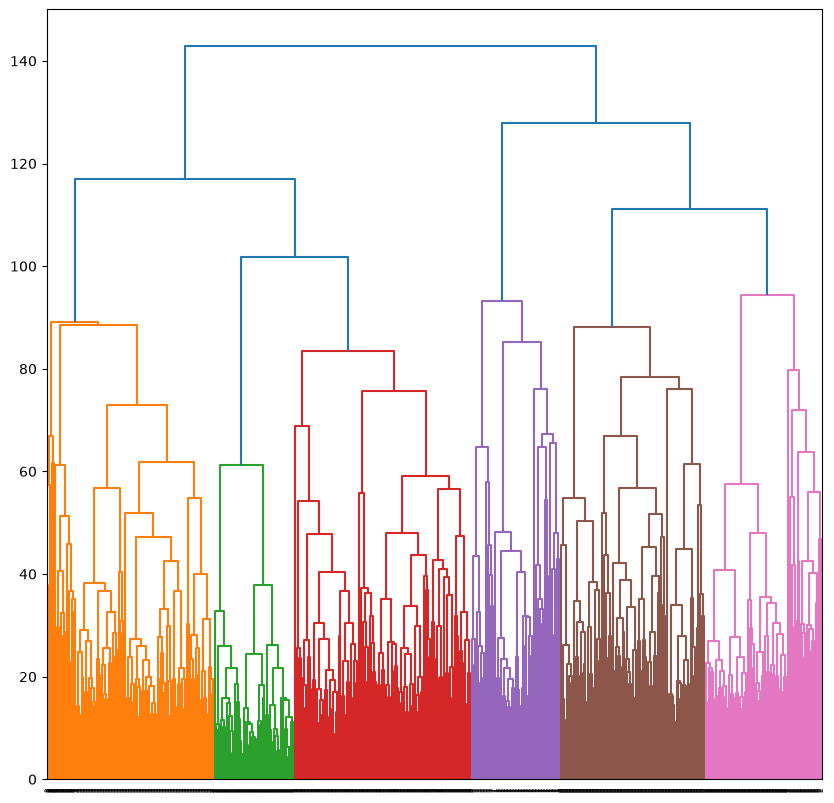

In [29]:
# Resample the data to include 500 samples
small_mnist_data, small_mnist_label = resample(mnist_data, mnist_label, n_samples=500, replace=False, random_state=69)

# Standardize the data
scaler = StandardScaler()
scaler.fit(small_mnist_data)
X_scaled = scaler.transform(small_mnist_data)

# Perform hierarchical clustering with 10 clusters
model = AgglomerativeClustering(n_clusters=10, compute_distances=True)
model.fit(X_scaled)

# Plot the dendrogram
plt.figure(figsize=(10, 10))
plot_dendrogram(model, labels=model.labels_)
plt.show()

**(e)** Using different cluster distance metrics (ward,single,average, etc.),
   what do the clusterings look like that are produced at the level of k=10 clusters?
   See the Clustering notebook for the needed Python code, including the fcluster
   method to retrieve 'plain' clusterings from the hierarchical clustering.

**Ward's method minimizes the sum of squared differences within all clusters, while maximum or complete linkage minimizes the maximum distance between observations of pairs of clusters. Average linkage minimizes the average distance between all pairs of observations in different clusters, and single linkage minimizes the distance between the closest observations in pairs of clusters. These different distance metrics can produce very different clusterings, as they capture different aspects of the underlying structure of the data.**

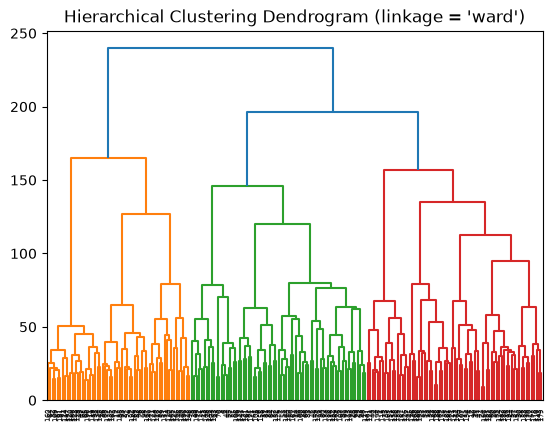

In [30]:
# Load the MNIST data
mnist = load_digits()

# Sample 200 random data points from the MNIST data
small_mnist_data, small_mnist_labels = resample(
    mnist.data,
    mnist.target,
    n_samples=200,
    replace=False
)

# Create an AgglomerativeClustering object with n_clusters=10 and linkage='ward'
agglomerative = AgglomerativeClustering(
    n_clusters=10,
    linkage='ward',
    compute_distances=True
)

# Fit the model to the data and generate a dendrogram
agg = agglomerative.fit(small_mnist_data)
plt.title("Hierarchical Clustering Dendrogram (linkage = 'ward')")
plot_dendrogram(agg)

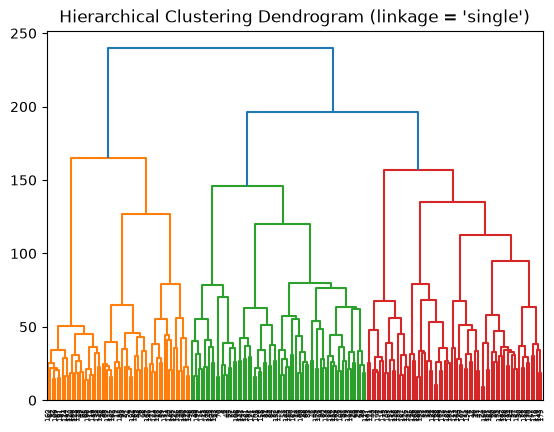

In [31]:
# Repeat the process with linkage='single'
agglomerative = AgglomerativeClustering(
    n_clusters=10,
    linkage='single',
    compute_distances=True
)
agglomerative.fit(small_mnist_data)
plt.title("Hierarchical Clustering Dendrogram (linkage = 'single')")
plot_dendrogram(agg)

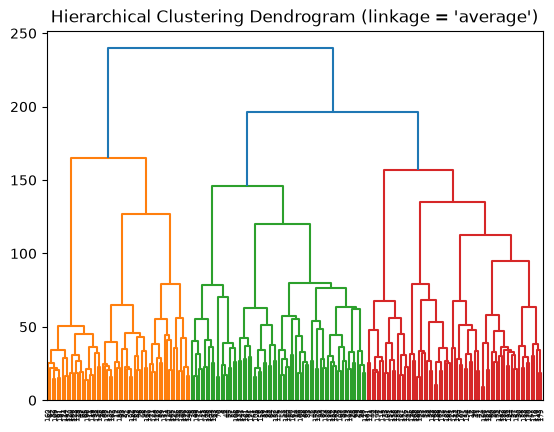

In [32]:
# Repeat the process with linkage='average'
agglomerative = AgglomerativeClustering(
    n_clusters=10,
    linkage='average',
    compute_distances=True
)
agglomerative.fit(small_mnist_data)
plt.title("Hierarchical Clustering Dendrogram (linkage = 'average')")
plot_dendrogram(agg)

**(f)** Do a DBSCAN clustering of the small dataset. Tweak the different parameters.

In [33]:
mnist = scipy.io.loadmat('3 Clustering of Handwritten Digits/mnist-original')
mnist_data = mnist["data"].T
mnist_labels = mnist["label"][0]

FileNotFoundError: [Errno 2] No such file or directory: '3 Clustering of Handwritten Digits/mnist-original.mat'

In [ ]:
# Sample 200 random data points from the MNIST data
small_mnist_data, small_mnist_labels = resample(
    mnist_data,
    mnist_labels,
    n_samples=200,
    replace=False,
    random_state=69
)

data_scaled = small_mnist_data/255.0

In [ ]:
for eps in range(1,15):
    # Create an instance of the DBSCAN class with the desired parameters
    dbscan = DBSCAN(eps=eps, min_samples=10)

    # Fit the DBSCAN model to the data and predict the clusters for each data point
    labels = dbscan.fit_predict(data_scaled)

    # Print the results
    print("\n".join(["eps value: " + str(eps), "Clusters present: " + str(np.unique(labels))]))
    print(", ".join(["Cluster sizes:"] + [str(x) for x in np.bincount(labels + 1)]))

eps value: 1
Clusters present: [-1]
Cluster sizes:, 200
eps value: 2
Clusters present: [-1]
Cluster sizes:, 200
eps value: 3
Clusters present: [-1]
Cluster sizes:, 200
eps value: 4
Clusters present: [-1]
Cluster sizes:, 200
eps value: 5
Clusters present: [-1]
Cluster sizes:, 200
eps value: 6
Clusters present: [-1  0]
Cluster sizes:, 189, 11
eps value: 7
Clusters present: [-1  0  1]
Cluster sizes:, 140, 50, 10
eps value: 8
Clusters present: [-1  0]
Cluster sizes:, 58, 142
eps value: 9
Clusters present: [-1  0]
Cluster sizes:, 6, 194
eps value: 10
Clusters present: [-1  0]
Cluster sizes:, 1, 199
eps value: 11
Clusters present: [0]
Cluster sizes:, 0, 200
eps value: 12
Clusters present: [0]
Cluster sizes:, 0, 200
eps value: 13
Clusters present: [0]
Cluster sizes:, 0, 200
eps value: 14
Clusters present: [0]
Cluster sizes:, 0, 200


**The eps parameter controls the maximum distance between two points in the same cluster, so a smaller eps value will result in fewer points being included in each cluster. This can be seen in the output, where the number of clusters and the sizes of the clusters change as the eps value is varied.**

**(g)** Try to compare the different clustering methods on the MNIST dataset in the same way
   the book does on the faces dataset on pp. 195-206.

In [ ]:
# Sample 200 random data points from the MNIST data
small_mnist_data, small_mnist_labels = resample(
    mnist_data,
    mnist_labels,
    n_samples=200,
    replace=False,
    random_state=69
)

X_scaled = small_mnist_data/255.0

In [ ]:
# Create a kmeans model with 10 clusters
kmeans = KMeans(n_clusters=10)

# Perform 10 random restarts of kmeans and calculate the ARI for each
for i in range(10):
  # Fit the model to the scaled data and predict the labels
  kmeans_labels = kmeans.fit_predict(X_scaled)

In [ ]:
# Set a range of eps values to try
eps_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Loop over the eps values
for eps in eps_range:
    # Create the DBSCAN model with the current eps value
    dbscan = DBSCAN(eps=eps, min_samples=2)
    
    # Fit the model to the data and predict the clusters for each data point
    dblabels = dbscan.fit_predict(X_scaled)

    # Print the results
    print("\n".join(["eps value: " + str(eps), "Clusters present: " + str(np.unique(dblabels))]))
    print(", ".join(["Cluster sizes:"] + [str(x) for x in np.bincount(dblabels + 1)]))
    
    # Calculate and print the ARI score for the current value of eps
    print("ARI K-Means vs DBSCAN: {:.2f}".format(adjusted_rand_score(kmeans_labels,dblabels)))

eps value: 1
Clusters present: [-1]
Cluster sizes:, 200
ARI K-Means vs DBSCAN: 0.00
eps value: 2
Clusters present: [-1  0]
Cluster sizes:, 198, 2
ARI K-Means vs DBSCAN: -0.00
eps value: 3
Clusters present: [-1  0  1]
Cluster sizes:, 195, 3, 2
ARI K-Means vs DBSCAN: -0.01
eps value: 4
Clusters present: [-1  0  1  2]
Cluster sizes:, 188, 2, 2, 8
ARI K-Means vs DBSCAN: -0.01
eps value: 5
Clusters present: [-1  0  1  2  3  4  5  6]
Cluster sizes:, 173, 7, 2, 2, 10, 2, 2, 2
ARI K-Means vs DBSCAN: -0.01
eps value: 6
Clusters present: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Cluster sizes:, 134, 22, 8, 3, 2, 3, 2, 2, 10, 2, 2, 2, 3, 3, 2
ARI K-Means vs DBSCAN: 0.00
eps value: 7
Clusters present: [-1  0  1  2  3  4  5  6  7  8  9 10 11]
Cluster sizes:, 74, 97, 3, 2, 4, 3, 3, 4, 2, 2, 2, 2, 2
ARI K-Means vs DBSCAN: 0.08
eps value: 8
Clusters present: [-1  0  1]
Cluster sizes:, 24, 174, 2
ARI K-Means vs DBSCAN: 0.02
eps value: 9
Clusters present: [-1  0  1]
Cluster sizes:, 3, 195, 2
ARI K-

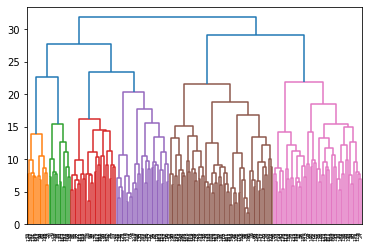

In [ ]:
# Create an AgglomerativeClustering object with n_clusters=10
agglomerative = AgglomerativeClustering(
    n_clusters=10,
    compute_distances=True
)

# Fit the model to the data
agg_labels = agglomerative.fit(X_scaled)
plot_dendrogram(agg)

In [ ]:
# Define the different label lists
label_lists = [    
    {"K-Means": kmeans_labels},     
    {"Agglomerative": agg_labels.labels_},     
    {"DBSCAN": dblabels}
]

# Loop through the label lists and compute the ARI score with each other list
for i, labels1 in enumerate(label_lists):
    for labels2 in label_lists[i+1:]:
        score = adjusted_rand_score(list(labels1.values())[0], list(labels2.values())[0])
        print("ARI {} vs {}: {:.2f}".format(list(labels1.keys())[0], list(labels2.keys())[0], score))

NameError: name 'kmeans_labels' is not defined

## 3. Training a neural network

In [ ]:
def train(net, train_values, train_labels, test_values, test_labels, num_epochs):
    x_train = torch.FloatTensor(train_values)
    x_test  = torch.FloatTensor(test_values)
    y_train = torch.LongTensor(train_labels.values)
    y_test  = torch.LongTensor(test_labels.values)

    # Wrap in DataLoader for batching
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
    test_loader  = DataLoader(TensorDataset(x_test,  y_test),  batch_size=32)

    # Setup
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

    # Training loop
    for epoch in range(num_epochs):
        net.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(net(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        net.eval()
        correct = total = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = net(X_batch).argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total   += y_batch.size(0)

        print(f"Epoch {epoch+1:>3} | Test acc: {correct/total:.4f}")

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.pool = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=2, kernel_size=(3, 3), stride=(1, 1), padding=1),
            nn.MaxPool2d(3, 3)
        )

        self.fc = nn.Sequential(
            nn.Linear(8712, 100),
            nn.ReLU(inplace=True),
            nn.Linear(100, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 10)
        )


    def forward(self, x):
        x = self.pool(x)
        x = x.view(-1, 8712)
        # x = self.fc(x)
        x = torch.sub(1.1, self.fc(x))

        return x

In [ ]:
net = Net()
net = train(net, data_train, labels_train, data_test, labels_test, 2)